In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import plotly.express as px

In [2]:
df = pd.read_excel("C:/Users/DELL/Downloads/Code/Data Mining/Data của thực hành/Online Retail.xlsx")
print(df.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/DELL/Downloads/Code/Data Mining/Data của thực hành/Online Retail.xlsx'

In [ ]:
# Chọn các cột cần thiết
df = df[['CustomerID','InvoiceNo','StockCode','Quantity','UnitPrice','Description','InvoiceDate','Country']]
print(df.head())

   CustomerID InvoiceNo StockCode  Quantity  UnitPrice  \
0     17850.0    536365    85123A         6       2.55   
1     17850.0    536365     71053         6       3.39   
2     17850.0    536365    84406B         8       2.75   
3     17850.0    536365    84029G         6       3.39   
4     17850.0    536365    84029E         6       3.39   

                           Description         InvoiceDate         Country  
0   WHITE HANGING HEART T-LIGHT HOLDER 2010-12-01 08:26:00  United Kingdom  
1                  WHITE METAL LANTERN 2010-12-01 08:26:00  United Kingdom  
2       CREAM CUPID HEARTS COAT HANGER 2010-12-01 08:26:00  United Kingdom  
3  KNITTED UNION FLAG HOT WATER BOTTLE 2010-12-01 08:26:00  United Kingdom  
4       RED WOOLLY HOTTIE WHITE HEART. 2010-12-01 08:26:00  United Kingdom  


In [ ]:
# Thống kê cơ bản
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   CustomerID   406829 non-null  float64       
 1   InvoiceNo    541909 non-null  object        
 2   StockCode    541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   UnitPrice    541909 non-null  float64       
 5   Description  540455 non-null  object        
 6   InvoiceDate  541909 non-null  datetime64[ns]
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
          CustomerID       Quantity      UnitPrice  \
count  406829.000000  541909.000000  541909.000000   
mean    15287.690570       9.552250       4.611114   
min     12346.000000  -80995.000000  -11062.060000   
25%     13953.000000       1.000000       1.250000   
50%     15152.000000       3.0000

In [ ]:
# Kiểm tra missing values
print(df.isna().sum())

CustomerID     135080
InvoiceNo           0
StockCode           0
Quantity            0
UnitPrice           0
Description      1454
InvoiceDate         0
Country             0
dtype: int64


In [ ]:
# Lấy danh sách quốc gia duy nhất
countries = df['Country'].unique()
print(countries)

['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Bahrain' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


In [ ]:
# Tính tổng giá trị đơn hàng
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Tạo dataframe mới
new_df = df[['CustomerID','InvoiceNo','StockCode','Quantity','TotalAmount','InvoiceDate','Country']]
new_df2 = df.copy()
print(id(new_df2) == id(df))  # tracemem tương đương

print(new_df.head())

False
   CustomerID InvoiceNo StockCode  Quantity  TotalAmount         InvoiceDate  \
0     17850.0    536365    85123A         6        15.30 2010-12-01 08:26:00   
1     17850.0    536365     71053         6        20.34 2010-12-01 08:26:00   
2     17850.0    536365    84406B         8        22.00 2010-12-01 08:26:00   
3     17850.0    536365    84029G         6        20.34 2010-12-01 08:26:00   
4     17850.0    536365    84029E         6        20.34 2010-12-01 08:26:00   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  


In [ ]:
# EDA : descriptive + missing + skewness
print("Dim df:", df.shape)
print("Dim new_df:", new_df.shape)


Dim df: (541909, 9)
Dim new_df: (541909, 7)


In [ ]:
# Tỉ lệ missing
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
print(missing_pct)


CustomerID     24.93
InvoiceNo       0.00
StockCode       0.00
Quantity        0.00
UnitPrice       0.00
Description     0.27
InvoiceDate     0.00
Country         0.00
TotalAmount     0.00
dtype: float64


In [ ]:
# Thống kê số liệu
print("Summary (Quantity, UnitPrice, TotalAmount)")
print(df[['Quantity','UnitPrice','TotalAmount']].describe())
print(new_df[['Quantity','TotalAmount']].describe())


Summary (Quantity, UnitPrice, TotalAmount)
            Quantity      UnitPrice    TotalAmount
count  541909.000000  541909.000000  541909.000000
mean        9.552250       4.611114      17.987795
std       218.081158      96.759853     378.810824
min    -80995.000000  -11062.060000 -168469.600000
25%         1.000000       1.250000       3.400000
50%         3.000000       2.080000       9.750000
75%        10.000000       4.130000      17.400000
max     80995.000000   38970.000000  168469.600000
            Quantity    TotalAmount
count  541909.000000  541909.000000
mean        9.552250      17.987795
std       218.081158     378.810824
min    -80995.000000 -168469.600000
25%         1.000000       3.400000
50%         3.000000       9.750000
75%        10.000000      17.400000
max     80995.000000  168469.600000


In [ ]:
#skewness
def skew_fun(x):
    x = x.dropna()
    m = x.mean()
    s = x.std()
    if s == 0:
        return np.nan
    return ((x - m)**3).mean() / s**3

print(new_df[['Quantity','TotalAmount']].apply(skew_fun))


Quantity      -0.264075
TotalAmount   -0.964384
dtype: float64


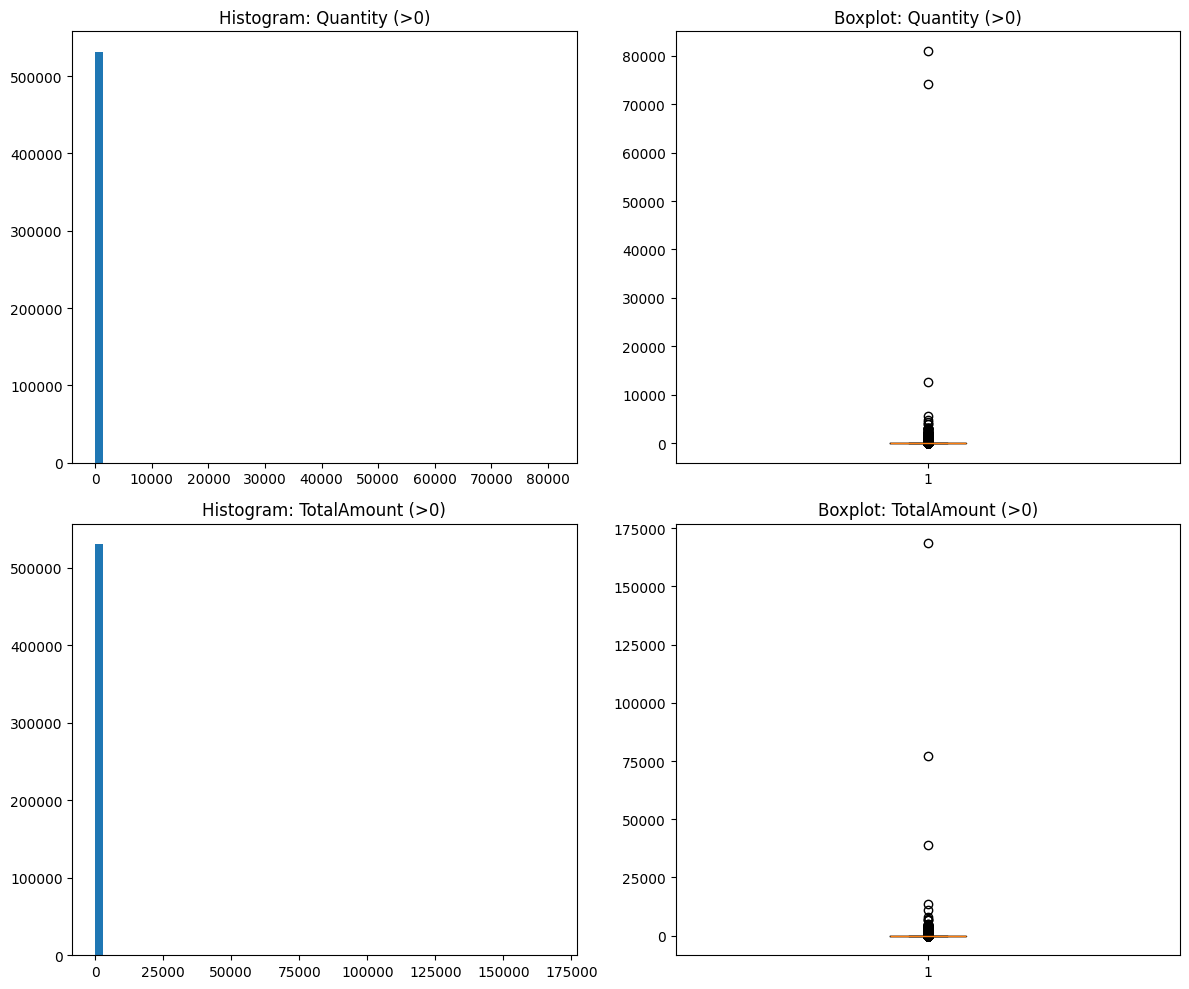

In [ ]:

# EDA : Biểu đồ đơn biến
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.hist(new_df['Quantity'][new_df['Quantity']>0], bins=60)
plt.title("Histogram: Quantity (>0)")
plt.subplot(2,2,2)
plt.boxplot(new_df['Quantity'][new_df['Quantity']>0])
plt.title("Boxplot: Quantity (>0)")
plt.subplot(2,2,3)
plt.hist(new_df['TotalAmount'][new_df['TotalAmount']>0], bins=60)
plt.title("Histogram: TotalAmount (>0)")
plt.subplot(2,2,4)
plt.boxplot(new_df['TotalAmount'][new_df['TotalAmount']>0])
plt.title("Boxplot: TotalAmount (>0)")
plt.tight_layout()
plt.show()


In [ ]:
# EDA : Ma trận tương quan
num_df = df[['Quantity','UnitPrice','TotalAmount']].dropna()
cor_mat = num_df.corr()
print(cor_mat)

             Quantity  UnitPrice  TotalAmount
Quantity     1.000000  -0.001235     0.886681
UnitPrice   -0.001235   1.000000    -0.162029
TotalAmount  0.886681  -0.162029     1.000000


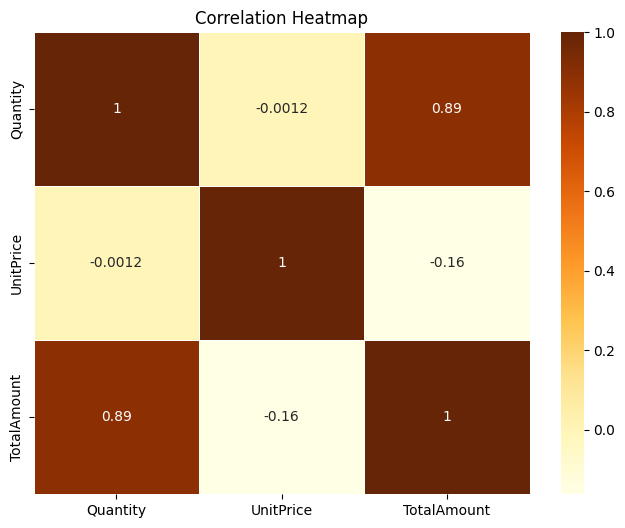

In [ ]:
# EDA : Ma trận tương quan
num_df = df[['Quantity','UnitPrice','TotalAmount']].dropna()
cor_mat = num_df.corr()
print(cor_mat)

plt.figure(figsize=(8,6))
sns.heatmap(cor_mat, annot=True, cmap='YlOrBr', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


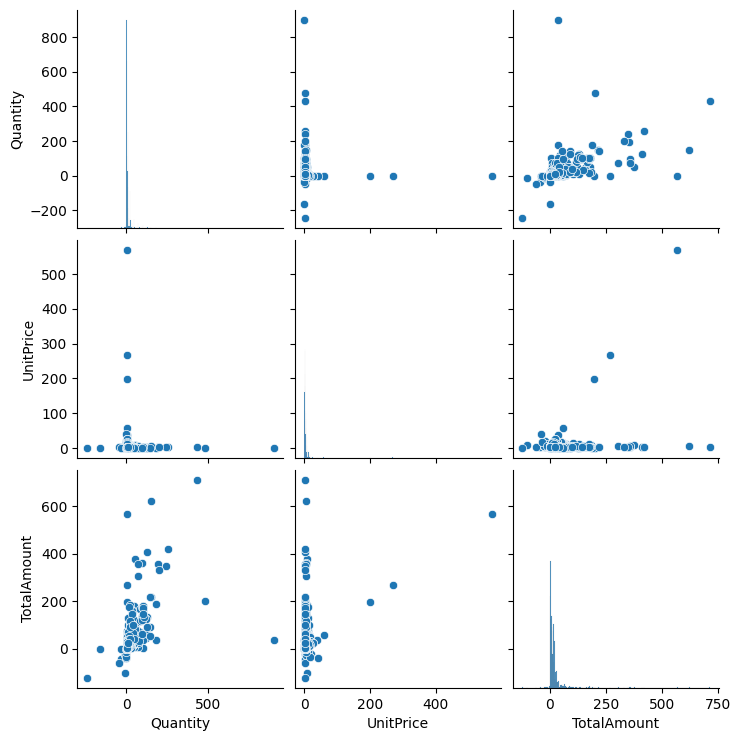

In [ ]:
# EDA 4: Scatterplot matrix
samp = num_df.sample(n=2000) if len(num_df) > 2000 else num_df
sns.pairplot(samp)
plt.show()

In [ ]:
#Nhóm các quốc gia theo Tổng Số Tiền Bán Hàng (TotalAmount)
country_price = new_df.groupby('Country')['Quantity'].sum().reset_index()
country_price = country_price.sort_values('Quantity', ascending=False)
print(country_price)

                 Country  Quantity
36        United Kingdom   4263829
24           Netherlands    200128
10                  EIRE    142637
14               Germany    117448
13                France    110480
0              Australia     83653
32                Sweden     35637
33           Switzerland     30325
31                 Spain     26824
20                 Japan     25218
3                Belgium     23152
25                Norway     19247
27              Portugal     16180
12               Finland     10666
6        Channel Islands      9479
9                Denmark      8188
19                 Italy      7999
7                 Cyprus      6317
30             Singapore      5234
1                Austria      4827
16             Hong Kong      4769
18                Israel      4353
26                Poland      3653
37           Unspecified      3300
5                 Canada      2763
17               Iceland      2458
15                Greece      1556
34                  

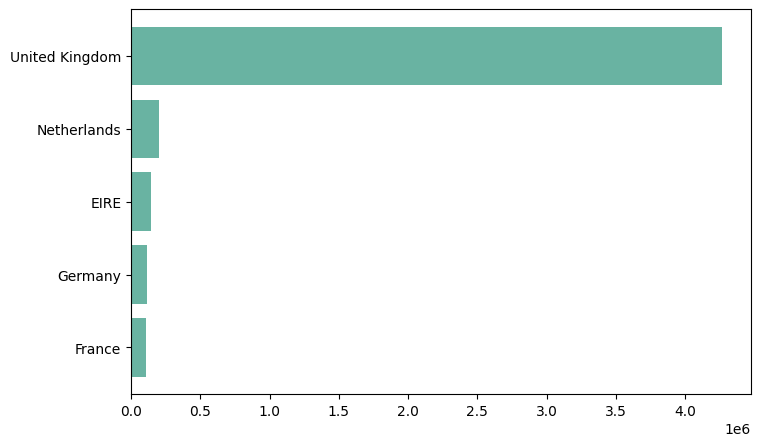

In [ ]:
#Top 5 quốc gia có mức mua hàng cao nhất
top5 = country_price.head(5)
plt.figure(figsize=(8,5))
plt.barh(top5['Country'], top5['Quantity'], color='#69b3a2')
plt.gca().invert_yaxis()
plt.show()

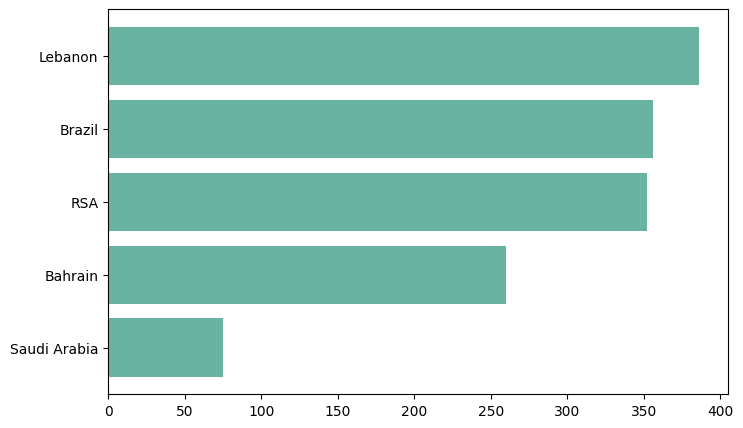

In [ ]:
#Top 5 quốc gia có mức mua hàng thấp nhất
low5 = country_price.tail(5)
plt.figure(figsize=(8,5))
plt.barh(low5['Country'], low5['Quantity'], color='#69b3a2')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Thêm đặc tính năm
new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'])
new_df['Year'] = new_df['InvoiceDate'].dt.year
print(new_df.head())

   CustomerID InvoiceNo StockCode  Quantity  TotalAmount         InvoiceDate  \
0     17850.0    536365    85123A         6        15.30 2010-12-01 08:26:00   
1     17850.0    536365     71053         6        20.34 2010-12-01 08:26:00   
2     17850.0    536365    84406B         8        22.00 2010-12-01 08:26:00   
3     17850.0    536365    84029G         6        20.34 2010-12-01 08:26:00   
4     17850.0    536365    84029E         6        20.34 2010-12-01 08:26:00   

          Country  Year  
0  United Kingdom  2010  
1  United Kingdom  2010  
2  United Kingdom  2010  
3  United Kingdom  2010  
4  United Kingdom  2010  


C:\Users\DELL\AppData\Local\Temp\ipykernel_16452\4092868547.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_16452\4092868547.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Year'] = new_df['InvoiceDate'].dt.year


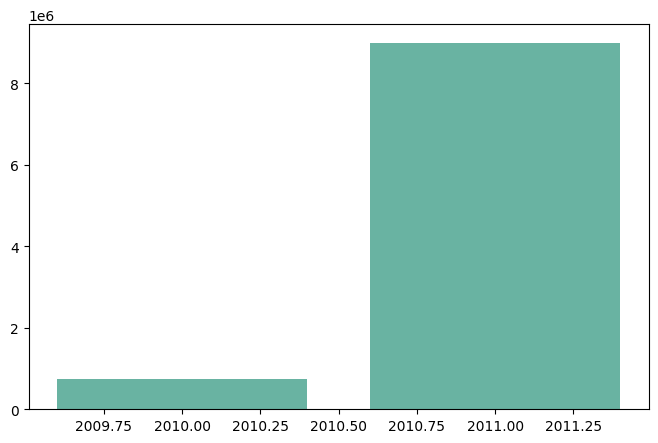

In [ ]:
#Vẽ đồ thị TotalAmount so với Năm
year_ttlamount = new_df.groupby('Year')['TotalAmount'].sum().reset_index()
plt.figure(figsize=(8,5))
plt.bar(year_ttlamount['Year'], year_ttlamount['TotalAmount'], color="#69b3a2")
plt.show()

In [ ]:
# Xóa giá trị thiếu
new_df = new_df.dropna()
print(new_df.isna().sum())

CustomerID     0
InvoiceNo      0
StockCode      0
Quantity       0
TotalAmount    0
InvoiceDate    0
Country        0
Year           0
dtype: int64


In [ ]:
# Nhóm theo số lượng khách hàng trong mỗi quốc gia
cus_id = new_df.groupby('Country')['CustomerID'].sum().reset_index()
cus_id = cus_id.sort_values('CustomerID', ascending=False)
print(cus_id)

                 Country    CustomerID
35        United Kingdom  5.626433e+09
14               Germany  1.200751e+08
10                  EIRE  1.103917e+08
13                France  1.076489e+08
23           Netherlands  3.419054e+07
30                 Spain  3.268929e+07
3                Belgium  2.571829e+07
32           Switzerland  2.377592e+07
26              Portugal  1.886480e+07
0              Australia  1.569300e+07
24                Norway  1.350765e+07
6        Channel Islands  1.128522e+07
18                 Italy  1.015666e+07
12               Finland  8.699324e+06
7                 Cyprus  7.715880e+06
31                Sweden  6.790083e+06
1                Austria  5.021102e+06
9                Denmark  4.876734e+06
19                 Japan  4.567292e+06
25                Poland  4.341972e+06
33                   USA  3.672086e+06
36           Unspecified  3.348046e+06
17                Israel  3.164467e+06
29             Singapore  2.918376e+06
5                 Canada 

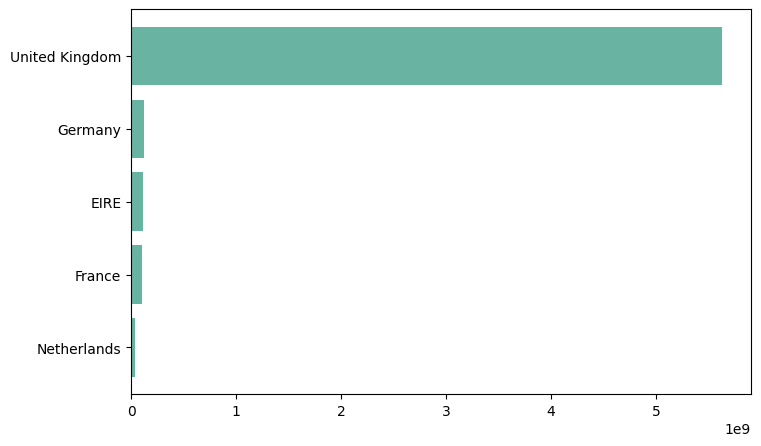

In [ ]:
# Lấy 5 quốc gia có số lượng khách hàng nhiều nhất
top5_cust = cus_id.head(5)
plt.figure(figsize=(8,5))
plt.barh(top5_cust['Country'], top5_cust['CustomerID'], color='#69b3a2')
plt.gca().invert_yaxis()
plt.show()

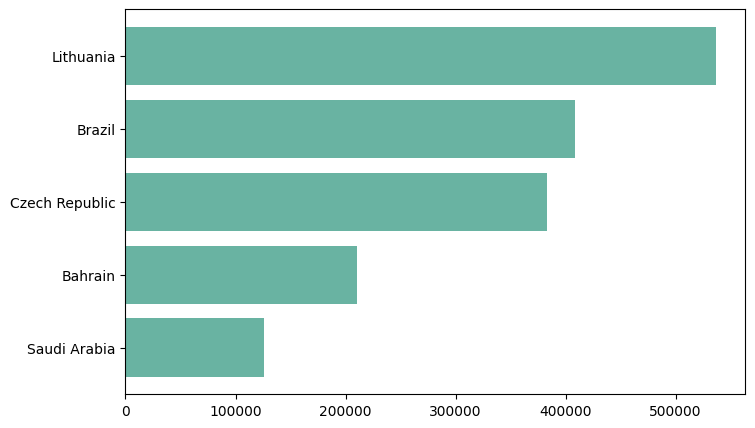

In [ ]:
#Top 5 quốc gia có số lượng khách hàng ít nhất
low5_cust = cus_id.tail(5)
plt.figure(figsize=(8,5))
plt.barh(low5_cust['Country'], low5_cust['CustomerID'], color='#69b3a2')
plt.gca().invert_yaxis()
plt.show()